## Упражнения


### Упражнение 1

- Рассмотрим в качестве сезонной составляющей периодический сигнал с периодом 12
```python
time = np.arange(144)
seasonal_12 = 20 + np.sin(2*np.pi*time/12)*20
```
- Используйте `seasonal_12` и компоненты `trend` и `residual` ниже, чтобы определить и построить аддитивную и мультипликативную модели
```python
trend = time * 2.65 + 100
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))
```
- Выполните сезонную декомпозицию с `seasonal_decompose` и `STL` для новых сигналов и сравните результаты с полученными в классе, где мы использовали приблизительный период.
### Упражнение 2
Загрузите два разных временных ряда следующим образом.
```python
import statsmodels.api as sm
ts_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values
print(len(ts_A))
ts_B = sm.datasets.get_rdataset("co2", "datasets").data["value"].values
print(len(ts_B))
```
- Постройте график двух временных рядов.
- Определите, выглядит ли временной ряд аддитивной или мультипликативной моделью.
- Определите основной период сезонной составляющей в двух временных рядах.
### Упражнение 3
- Разложите `ts_A` и `ts_B` с помощью `seasonal_decompose` и `STL`.
- Прокомментируйте полученные результаты.
from statsmodels.tsa.seasonal import season_decompose, STL

**Выполнение упражнений**

**Упражнение 1**

In [36]:
# Подготовка синтетических рядов
time = np.arange(144)
seasonal_12 = 20 + np.sin(2 * np.pi * time / 12) * 20
trend = time * 2.65 + 100
residuals = np.random.normal(loc=0.0, scale=3.0, size=len(time))

additive_12 = trend + seasonal_12 + residuals

# Для мультипликативной модели используем положительный сезонный фактор вокруг 1.
seasonal_shifted = seasonal_12 - seasonal_12.min() + 1.0
seasonal_factor = seasonal_shifted / np.mean(seasonal_shifted)
residual_factor = 1 + residuals / 100.0
multiplicative_12 = trend * seasonal_factor * residual_factor

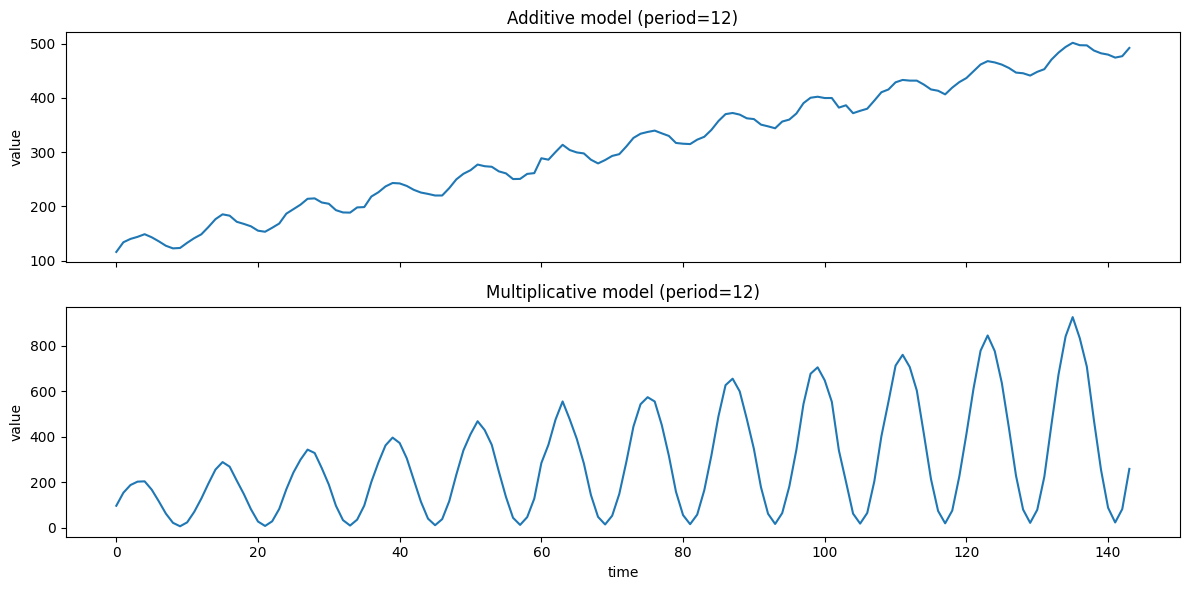

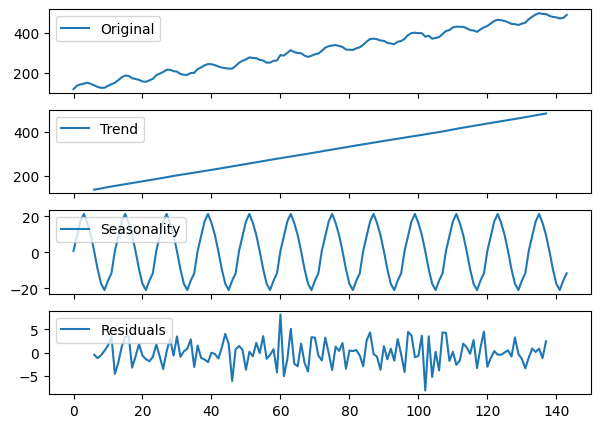

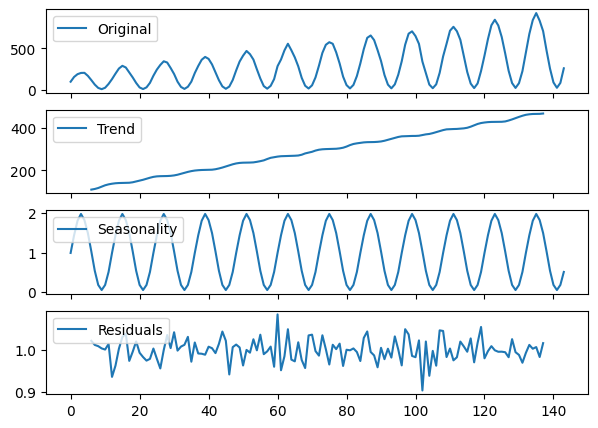

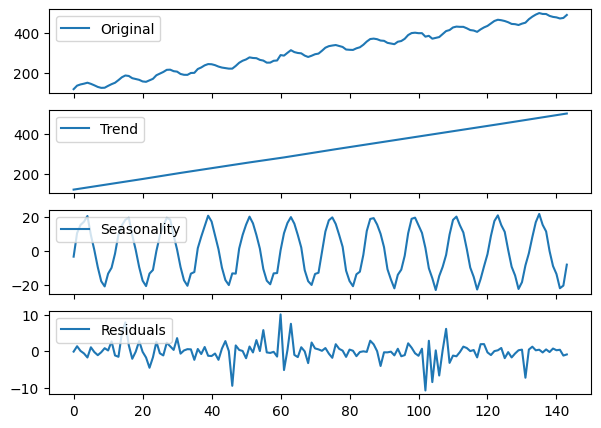

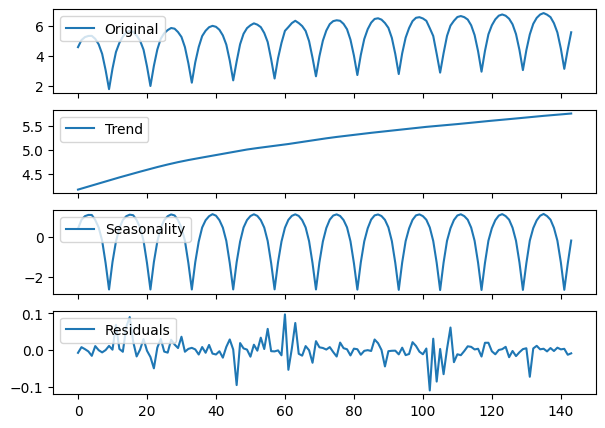

In [37]:
# Визуализация моделей
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time, additive_12)
axes[0].set_title("Additive model (period=12)")
axes[0].set_ylabel("value")

axes[1].plot(time, multiplicative_12)
axes[1].set_title("Multiplicative model (period=12)")
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
plt.tight_layout()
plt.show()

# Декомпозиции с истинным period=12
add_dec = seasonal_decompose(x=additive_12, model="additive", period=12)
seas_decomp_plots(additive_12, add_dec)

mul_dec = seasonal_decompose(x=multiplicative_12, model="multiplicative", period=12)
seas_decomp_plots(multiplicative_12, mul_dec)

stl_add = STL(endog=additive_12, period=12, robust=True).fit()
seas_decomp_plots(additive_12, stl_add)

# Для мультипликативной структуры STL применяем на логарифме.
stl_mul_log = STL(endog=np.log(multiplicative_12), period=12, robust=True).fit()
seas_decomp_plots(np.log(multiplicative_12), stl_mul_log)

**Упражнение 2**

In [38]:
# Загрузка данных
import pandas as pd
import statsmodels.api as sm

def load_rdataset_values(name: str, package: str = "datasets"):
    try:
        ds = sm.datasets.get_rdataset(name, package, cache=True)
        df = ds.data
    except Exception:
        # Для CO2 используем встроенный датасет statsmodels, если RDataset недоступен.
        if name.lower() == "co2" and hasattr(sm.datasets, "co2"):
            df = sm.datasets.co2.load_pandas().data
        else:
            raise

    if "value" in df.columns:
        values = df["value"].to_numpy(dtype=float)
    else:
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        values = df[num_cols[-1]].to_numpy(dtype=float)

    return values[np.isfinite(values)]

ts_A = load_rdataset_values("AirPassengers")
ts_B = load_rdataset_values("co2")
print("len(ts_A)=", len(ts_A), "len(ts_B)=", len(ts_B))

len(ts_A)= 144 len(ts_B)= 2225


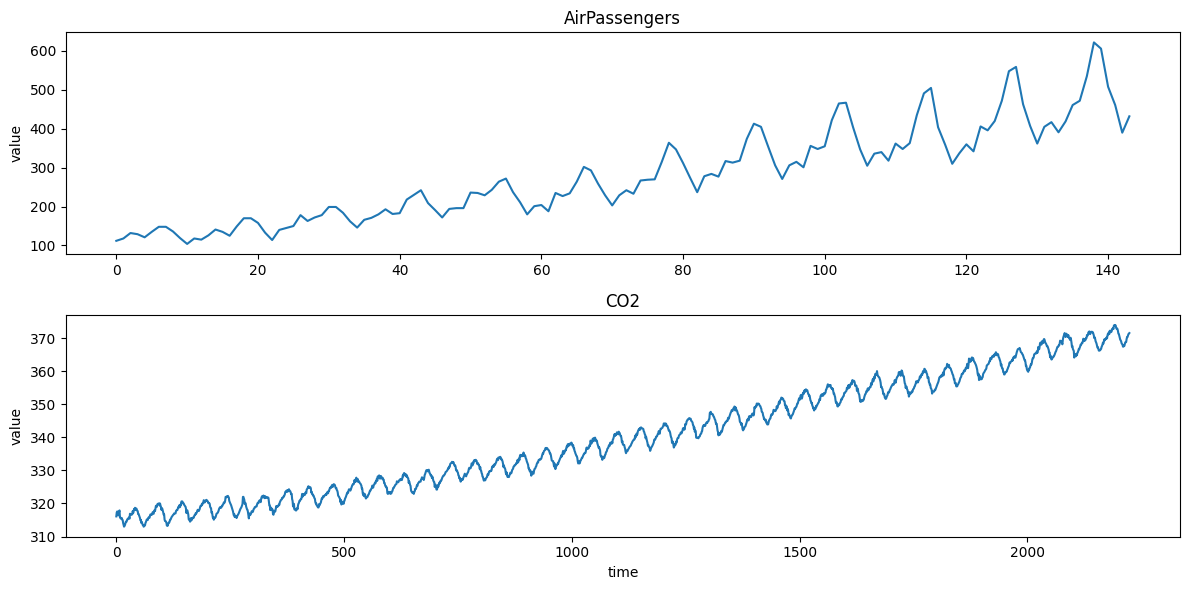

Estimated ts_A: freq=0.0833, period=12.00 -> 12
Estimated ts_B: freq=0.0193, period=51.74 -> 52


In [39]:
# Визуализация рядов
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(ts_A)
axes[0].set_title("AirPassengers")
axes[0].set_ylabel("value")

axes[1].plot(ts_B)
axes[1].set_title("CO2")
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
plt.tight_layout()
plt.show()

# Оценка доминирующего периода через FFT
def estimate_period_fft(signal, min_freq=0.01):
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]

    slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1)
    detrended = signal - (np.arange(len(signal)) * slope + intercept)

    fft_values = fft(detrended)
    frequencies = np.fft.fftfreq(len(fft_values))

    mask = frequencies > min_freq
    positive_frequencies = frequencies[mask]
    magnitudes = np.abs(fft_values)[mask]

    dominant_frequency = positive_frequencies[np.argmax(magnitudes)]
    dominant_period = 1 / dominant_frequency
    return dominant_period, dominant_frequency

period_A_est, freq_A = estimate_period_fft(ts_A, min_freq=0.01)
period_B_est, freq_B = estimate_period_fft(ts_B, min_freq=0.01)

period_A_i = int(round(period_A_est))
period_B_i = int(round(period_B_est))
print(f"Estimated ts_A: freq={freq_A:.4f}, period={period_A_est:.2f} -> {period_A_i}")
print(f"Estimated ts_B: freq={freq_B:.4f}, period={period_B_est:.2f} -> {period_B_i}")

**Выводы по упражнению 2:**

- `ts_A` лучше описывается мультипликативной моделью, так как амплитуда сезонных колебаний увеличивается вместе с уровнем ряда.<br>
`ts_B` лучше описывается аддитивной моделью, так как амплитуда сезонных колебаний более стабильна.
- По FFT в текущей реализации получаем доминирующий период около 12 для `ts_A` и около 52 для `ts_B`


**Упражнение 3**

In [40]:
import pandas as pd

ts_A_s = pd.Series(ts_A, dtype=float)
ts_B_s = pd.Series(ts_B, dtype=float).interpolate(limit_direction="both")

period_A = int(period_A_i) if "period_A_i" in globals() else 12
period_B = int(period_B_i) if "period_B_i" in globals() else 12
print("Using periods:", period_A, period_B)

def seas_decomp_plots(original, decomposition):
    _, axes = plt.subplots(4, 1, sharex=True, sharey=False, figsize=(7, 5))
    axes[0].plot(original, label='Original')
    axes[0].legend(loc='upper left')
    axes[1].plot(decomposition.trend, label='Trend')
    axes[1].legend(loc='upper left')
    axes[2].plot(decomposition.seasonal, label='Seasonality')
    axes[2].legend(loc='upper left')
    axes[3].plot(decomposition.resid, label='Residuals')
    axes[3].legend(loc='upper left')
    plt.show()

Using periods: 12 52


**seasonal_decompose**

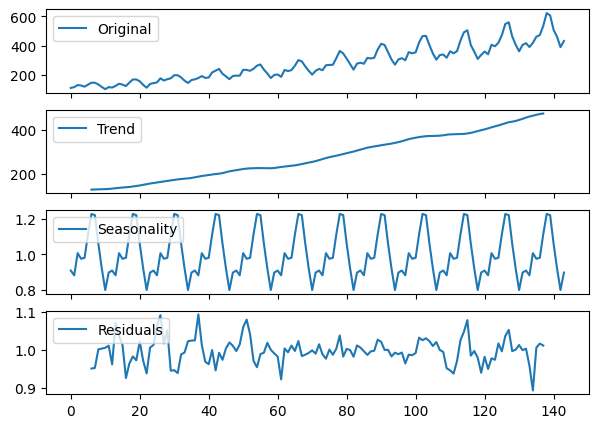

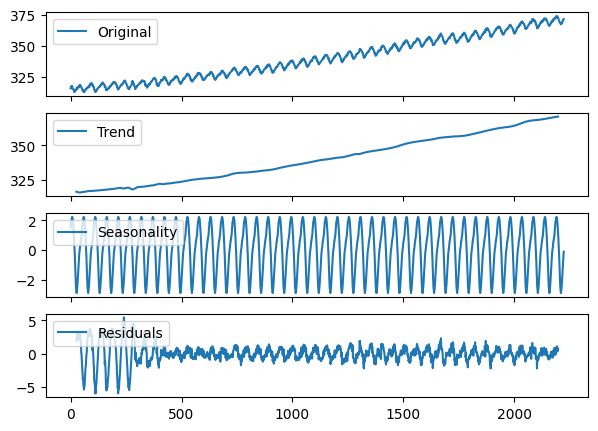

In [41]:
dec_A = seasonal_decompose(x=ts_A_s, model="multiplicative", period=period_A)
seas_decomp_plots(ts_A_s.to_numpy(), dec_A)
dec_B = seasonal_decompose(x=ts_B_s, model="additive", period=period_B)
seas_decomp_plots(ts_B_s.to_numpy(), dec_B)
plt.show()

**STL**

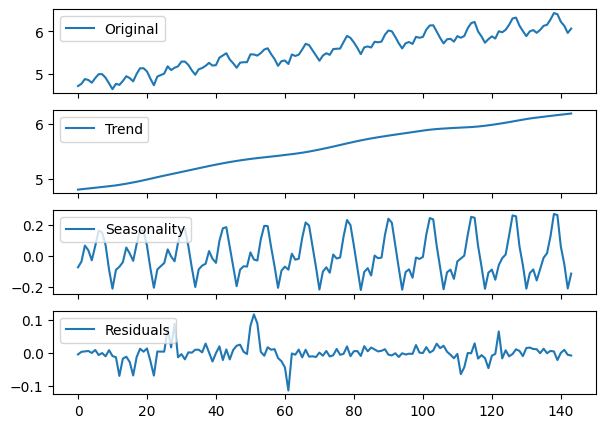

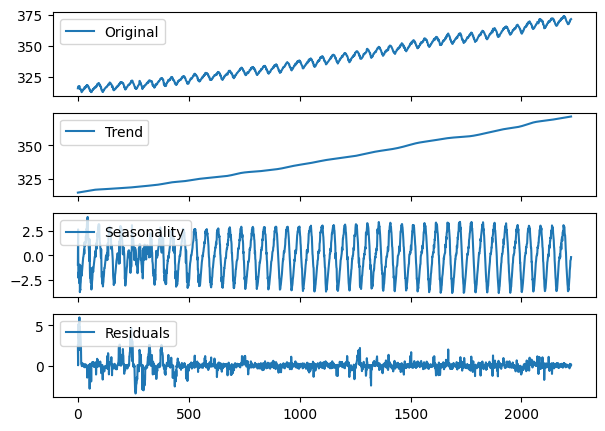

In [42]:
stl_A = STL(endog=np.log(ts_A_s), period=period_A, robust=True).fit()
seas_decomp_plots(np.log(ts_A_s.to_numpy()), stl_A)

stl_B = STL(endog=ts_B_s, period=period_B, robust=True).fit()
seas_decomp_plots(ts_B_s.to_numpy(), stl_B)

**Выводы по упражнению 3:**

Для `ts_A` STL обычно лучше отделяет тренд от сезонности, так как сезонность выглядит мультипликативной.<br>
Для `ts_B` аддитивная модель дает устойчивую сезонную компоненту
